In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

DRIVE = "/content/drive/MyDrive/volatility-forecast"
drive.mount("/content/drive", force_remount=True)
os.chdir(DRIVE)

for m in list(sys.modules):   # Colab caches imports; drop stale src modules
    if m.startswith('src'):
        del sys.modules[m]

from src.retrain import (FEATURES, TARGET, LABEL_DELAY,
                         fit_har_frame, simulate_retrain, AdwinStream)
from src.metrics import qlike
from src.drift import psi


Mounted at /content/drive


In [2]:
df = pd.read_csv('data/processed/dataset.csv', index_col=0, parse_dates=True)
df = df.iloc[21:-21]          # drop 21-row rolling warmup head + 21-row forward-target tail
df.index.name = 'date'
assert len(df) == 3831, f"expected 3831, got {len(df)}"   # must match the 03-07 work frame
print(df.shape)


(3831, 21)


In [3]:
# --- check 1: initial fit reproduces the static-HAR beta from stages 06/07 ---
beta0 = fit_har_frame(df.iloc[:1008])
print('initial beta :', np.round(beta0, 4))
print('expected     : [0.0048 0.0258 0.201  0.2949]   (static HAR, stages 06/07)')

# --- check 2: no-retrain baseline = engine with a trigger that never fires ---
never_fire = lambda i, loss_history, visible_indices, df: False
no_retrain_log = simulate_retrain(df, never_fire, train_window=1008, start=1008)
print('\nno_retrain: rows =', len(no_retrain_log),
      '| n_retrains =', int(no_retrain_log['n_retrains'].iloc[-1]),
      '| mean QLIKE =', round(no_retrain_log['loss'].mean(), 5))

# --- check 3: causality unit test -- the newest loss a trigger could see on
#     day i must be at least LABEL_DELAY days old ---
nv = no_retrain_log.attrs['newest_visible']
start = no_retrain_log.attrs['start']
viol = [(i, v) for i, v in zip(range(start, len(df)), nv) if v >= 0 and v > i - LABEL_DELAY]
assert not viol, f"look-ahead violation at {viol[:3]}"
print('causality OK : newest visible loss <= i - 21 for all',
      sum(v >= 0 for v in nv), 'days with a matured loss')

no_retrain_log.head()


initial beta : [0.0048 0.0258 0.201  0.2949]
expected     : [0.0048 0.0258 0.201  0.2949]   (static HAR, stages 06/07)

no_retrain: rows = 2823 | n_retrains = 0 | mean QLIKE = 0.07495
causality OK : newest visible loss <= i - 21 for all 2802 days with a matured loss


,i,y_pred,y_true,retrain_triggered,n_retrains,model_age,loss
date,,,,,,,
2015-02-05,1008,0.009880,0.006508,False,0,0,0.076187
2015-02-06,1009,0.009672,0.007571,False,0,1,0.027683
2015-02-09,1010,0.009174,0.007643,False,0,2,0.015694
2015-02-10,1011,0.010017,0.007007,False,0,3,0.056886
2015-02-11,1012,0.009676,0.007027,False,0,4,0.046127


In [4]:
# Periodic baselines: retrain every k days regardless of performance.
def make_periodic_trigger(k, start=1008):
    def trigger(i, loss_history, visible_indices, df):
        return i > start and (i - start) % k == 0
    return trigger

results = {'no_retrain': no_retrain_log}

for k in (21, 63, 252):
    results[f'periodic_{k}'] = simulate_retrain(df, make_periodic_trigger(k),
                                                train_window=1008, start=1008)

summary = pd.DataFrame({
    name: {'n_retrains': int(lg['n_retrains'].iloc[-1]),
           'mean_QLIKE': lg['loss'].mean(),
           'median_QLIKE': lg['loss'].median()}
    for name, lg in results.items()
}).T
print(summary.round(5))


              n_retrains  mean_QLIKE  median_QLIKE
no_retrain           0.0     0.07495       0.02717
periodic_21        134.0     0.07709       0.02967
periodic_63         44.0     0.07654       0.02802
periodic_252        11.0     0.07709       0.02844


In [5]:
# ADWIN trigger. The detector watches a binary stream: for each newly
# matured loss, 1 if the model's QLIKE was worse than persistence
# (forecast = trailing rv21) that day, else 0. Comparing against
# persistence removes the shared volatility level, so the stream tracks
# "is the model losing ground", not "did volatility go up".
def make_adwin_trigger(det, start=1008):
    state = {'n_consumed': 0, 'last_retrain': start}
    diagnostics = []

    def trigger(i, loss_history, visible_indices, df):
        triggered = False
        while state['n_consumed'] < len(visible_indices):
            k = state['n_consumed']
            s = visible_indices[k]
            state['n_consumed'] += 1
            if s < state['last_retrain']:
                continue   # judge each model version on its own record only
            loss_model = loss_history[k]
            # persistence loss for day s: its label has matured (s <= i - 21)
            loss_persistence = qlike(df[TARGET].iloc[s], df['rv21'].iloc[s])
            if det.update(1.0 if loss_model > loss_persistence else 0.0):
                mu0, mu1, n0, n1 = det.last_cut
                diagnostics.append({'i': i, 'date': df.index[i],
                                    'mu_old': mu0, 'mu_recent': mu1,
                                    'gap': mu1 - mu0, 'n0': n0, 'n1': n1,
                                    'direction': 'WORSE' if mu1 > mu0 else 'better'})
                triggered = True
        if triggered:
            det.reset()
            state['last_retrain'] = i
        return triggered

    return trigger, diagnostics


# adwin_raw: plain two-sided ADWIN -- fires on any mean change, either direction
trigger, diag_raw = make_adwin_trigger(AdwinStream(delta=0.002, min_n=30))
adwin_raw_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['adwin_raw'] = adwin_raw_log
assert int(adwin_raw_log['n_retrains'].iloc[-1]) == 26   # reproducibility check

diag_raw_df = pd.DataFrame(diag_raw)
diag_raw_df['fold'] = (diag_raw_df['i'] - 1008) // 252
print(diag_raw_df.round({'mu_old': 3, 'mu_recent': 3, 'gap': 3})
      [['date', 'fold', 'mu_old', 'mu_recent', 'gap', 'direction']].to_string(index=False))
print('\nWORSE fires:', (diag_raw_df['direction'] == 'WORSE').sum(), '/', len(diag_raw_df))

# per-fold QLIKE: adwin_raw vs no_retrain
def fold_ids(lg):
    """Fold id per log row; folds are 252-day blocks starting at row 1008."""
    fid = ((lg['i'] - 1008) // 252).to_numpy().copy()
    fid[fid >= 11] = -1        # tail rows beyond fold 10
    return fid

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(adwin_raw_log)).mean(),
                         'adwin_raw': adwin_raw_log['loss'].groupby(fold_ids(adwin_raw_log)).mean()}).drop(index=-1)
per_fold['diff'] = per_fold['adwin_raw'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


      date  fold  mu_old  mu_recent    gap direction
2016-02-12     1   0.355      1.000  0.645     WORSE
2016-05-13     1   0.000      1.000  1.000     WORSE
2016-08-10     1   1.000      0.061 -0.939    better
2016-10-20     1   0.000      1.000  1.000     WORSE
2017-01-26     1   0.212      1.000  0.788     WORSE
2017-05-25     2   1.000      0.000 -1.000    better
2017-10-25     2   0.171      1.000  0.829     WORSE
2018-02-12     3   0.905      0.083 -0.821    better
2018-05-17     3   0.781      0.000 -0.781    better
2018-09-19     3   0.170      0.842  0.672     WORSE
2018-12-10     3   0.000      0.800  0.800     WORSE
2019-02-22     4   1.000      0.050 -0.950    better
2019-12-16     4   0.188      0.688  0.499     WORSE
2020-03-25     5   0.132      1.000  0.868     WORSE
2020-07-01     5   0.025      1.000  0.975     WORSE
2021-08-12     6   0.408      1.000  0.592     WORSE
2021-10-22     6   0.909      0.000 -0.909    better
2022-03-22     7   0.097      0.654  0.557    

In [6]:
# adwin_directional: one-sided minimum-evidence variant. Only fire when
# the RECENT mean is worse (one_sided), by at least 0.2 (gap_min), with
# at least 21 points in the recent window (n1_min). This screens out
# fires on improvements and on tiny or noisy gaps.
det = AdwinStream(delta=0.002, min_n=30, one_sided=True, gap_min=0.2, n1_min=21)
trigger, diag_directional = make_adwin_trigger(det)
adwin_directional_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['adwin_directional'] = adwin_directional_log

diag_dir_df = pd.DataFrame(diag_directional)
if len(diag_dir_df):
    diag_dir_df['fold'] = (diag_dir_df['i'] - 1008) // 252
    print(diag_dir_df.round({'mu_old': 3, 'mu_recent': 3, 'gap': 3})
          [['date', 'fold', 'mu_old', 'mu_recent', 'gap', 'n0', 'n1']].to_string(index=False))
print('\nn_retrains :', int(adwin_directional_log['n_retrains'].iloc[-1]),
      '| mean QLIKE :', round(adwin_directional_log['loss'].mean(), 5))
# reference (earlier runs): periodic_63 0.07654 | no_retrain 0.07495 |
#                           adwin_raw 0.07469 | oracle_single_retrain 0.07391

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(adwin_directional_log)).mean(),
                         'adwin_directional': adwin_directional_log['loss'].groupby(fold_ids(adwin_directional_log)).mean()}).drop(index=-1)
per_fold['diff'] = per_fold['adwin_directional'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


      date  fold  mu_old  mu_recent   gap  n0  n1
2016-02-16     1   0.349      0.913 0.564 215  23
2016-06-01     1   0.000      0.682 0.682  32  22
2017-02-02     1   0.264      0.857 0.594 129  21
2018-01-05     2   0.435      0.963 0.527 186  27
2018-04-17     3   0.074      0.773 0.699  27  22
2018-09-12     3   0.054      0.630 0.576  56  27
2018-12-10     3   0.000      0.762 0.762  20  21
2019-12-18     4   0.201      0.676 0.475 204  34
2020-04-06     5   0.094      0.773 0.679  32  22
2020-07-17     5   0.000      0.682 0.682  29  22
2021-08-13     6   0.419      1.000 0.581 229  22
2022-04-04     7   0.381      0.957 0.575 118  23

n_retrains : 12 | mean QLIKE : 0.07448

     no_retrain  adwin_directional    diff
0       0.0647             0.0647  0.0000
1       0.0792             0.0727 -0.0065
2       0.0714             0.0785  0.0071
3       0.0839             0.0951  0.0112
4       0.0741             0.0712 -0.0030
5       0.1922             0.1928  0.0006
6       0.0592

In [7]:
# oracle_single_retrain: retrain exactly once, at the first ADWIN
# detection inside f07 (2022-03-22 on the real data, from the adwin_raw
# diagnostics above). This uses hindsight -- we already know f07 is
# where the drift was -- so it is an upper bound for single-retrain
# policies, not a deployable strategy.
f07_detections = diag_raw_df[diag_raw_df['fold'] == 7]
assert len(f07_detections), "adwin_raw never fired in f07"
retrain_i = int(f07_detections['i'].iloc[0])
print('single retrain at i =', retrain_i, '=', df.index[retrain_i].date())

def oracle_trigger(i, loss_history, visible_indices, df, fire_at=retrain_i):
    return i == fire_at

oracle_log = simulate_retrain(df, oracle_trigger, train_window=1008, start=1008)
results['oracle_single_retrain'] = oracle_log

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(oracle_log)).mean(),
                         'oracle_single_retrain': oracle_log['loss'].groupby(fold_ids(oracle_log)).mean()}).drop(index=-1)
per_fold['diff'] = per_fold['oracle_single_retrain'] - per_fold['no_retrain']
print(per_fold.round(4))
print('\nmean QLIKE  oracle_single_retrain :', round(oracle_log['loss'].mean(), 5),
      '| no_retrain : 0.07495')


single retrain at i = 2802 = 2022-03-22
    no_retrain  oracle_single_retrain    diff
0       0.0647                 0.0647  0.0000
1       0.0792                 0.0792  0.0000
2       0.0714                 0.0714  0.0000
3       0.0839                 0.0839  0.0000
4       0.0741                 0.0741  0.0000
5       0.1922                 0.1922  0.0000
6       0.0592                 0.0592  0.0000
7       0.0621                 0.0436 -0.0185
8       0.0132                 0.0266  0.0133
9       0.0395                 0.0383 -0.0011
10      0.0948                 0.0916 -0.0032

mean QLIKE  oracle_single_retrain : 0.07391 | no_retrain : 0.07495


In [8]:
# PSI trigger: watches the FEATURE distribution P(X) instead of the loss.
# Features are observable the same day (no label needed), so this
# trigger has no 21-day delay -- its potential edge over loss triggers.
def make_psi_trigger(threshold=0.25, recent_win=63, spacing=21,
                     train_window=1008, start=1008, label_delay=21):
    state = {'ref_begin': 0, 'ref_end': start, 'last_retrain': -10**9}
    diagnostics = []

    def trigger(i, loss_history, visible_indices, df):
        if i - state['last_retrain'] < spacing:   # cooldown between fires
            return False
        if i - recent_win < 0:
            return False
        vals = {}
        for f in FEATURES:
            ref = df[f].iloc[state['ref_begin']:state['ref_end']].values
            recent = df[f].iloc[i - recent_win:i + 1].values   # features observable same day
            vals[f] = psi(ref, recent)
        worst = max(vals, key=vals.get)
        if vals[worst] > threshold:
            # move the reference to the window the engine is about to retrain on
            end = i - label_delay
            state['ref_begin'], state['ref_end'] = max(0, end - train_window), end
            state['last_retrain'] = i
            diagnostics.append({'i': i, 'date': df.index[i], 'worst_feat': worst,
                                **{f'psi_{f}': round(v, 3) for f, v in vals.items()}})
            return True
        return False

    return trigger, diagnostics


# standard textbook threshold: PSI > 0.25 = large shift
trigger, diag_psi = make_psi_trigger(threshold=0.25)
psi_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['psi'] = psi_log

diag_psi_df = pd.DataFrame(diag_psi)
if len(diag_psi_df):
    diag_psi_df['fold'] = (diag_psi_df['i'] - 1008) // 252
    print(diag_psi_df[['date', 'fold', 'worst_feat', 'psi_rv1', 'psi_rv5', 'psi_rv21']]
          .to_string(index=False))
print('\nn_retrains :', int(psi_log['n_retrains'].iloc[-1]),
      '| mean QLIKE :', round(psi_log['loss'].mean(), 5))
# reference (earlier runs): periodic_63 0.07654 | no_retrain 0.07495 |
#   adwin_raw 0.07469 | adwin_directional 0.07448 | oracle_single_retrain 0.07391

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(psi_log)).mean(),
                         'adwin_directional': results['adwin_directional']['loss'].groupby(fold_ids(psi_log)).mean(),
                         'psi': psi_log['loss'].groupby(fold_ids(psi_log)).mean()}).drop(index=-1)
per_fold['psi_minus_no_retrain'] = per_fold['psi'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


      date  fold worst_feat  psi_rv1  psi_rv5  psi_rv21
2015-02-05     0       rv21    0.086    0.185     3.046
2015-03-09     0       rv21    0.060    0.208     3.010
2015-04-08     0       rv21    0.086    1.402     3.849
2015-05-07     0       rv21    0.228    2.516     3.954
2015-06-08     0       rv21    0.237    1.485     6.506
2015-07-08     0       rv21    0.292    2.425     6.331
2015-08-06     0       rv21    0.109    1.427     5.071
2015-09-04     0       rv21    0.128    0.428     2.702
2015-10-06     0       rv21    1.319    0.524     4.075
2015-11-04     0       rv21    0.266    1.706     4.264
2015-12-04     0       rv21    0.178    0.336     5.039
2016-01-06     0       rv21    0.262    0.458     5.201
2016-02-05     1       rv21    0.337    2.046     5.237
2016-03-08     1       rv21    0.428    5.110     9.310
2016-04-07     1       rv21    0.366    1.432     3.107
2016-05-06     1       rv21    0.139    0.345     2.055
2016-06-07     1        rv5    0.150    2.477   

In [9]:
# psi_budget_matched: threshold raised (tuned after the fact) until the
# PSI trigger fires about as often as adwin_directional, so the two can
# be compared at the same retrain budget. Diagnostic only -- picking the
# threshold this way uses full-sample knowledge.
trigger, diag_psi_matched = make_psi_trigger(threshold=10.7, recent_win=63, spacing=21)
psi_budget_matched_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['psi_budget_matched'] = psi_budget_matched_log

diag_psi_matched_df = pd.DataFrame(diag_psi_matched)
if len(diag_psi_matched_df):
    diag_psi_matched_df['fold'] = (diag_psi_matched_df['i'] - 1008) // 252
    print(diag_psi_matched_df[['date', 'fold', 'worst_feat', 'psi_rv1', 'psi_rv5', 'psi_rv21']]
          .to_string(index=False))
print('\nn_retrains :', int(psi_budget_matched_log['n_retrains'].iloc[-1]),
      '| mean QLIKE :', round(psi_budget_matched_log['loss'].mean(), 5))

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(psi_budget_matched_log)).mean(),
                         'adwin_directional': results['adwin_directional']['loss'].groupby(fold_ids(psi_budget_matched_log)).mean(),
                         'psi_budget_matched': psi_budget_matched_log['loss'].groupby(fold_ids(psi_budget_matched_log)).mean()}).drop(index=-1)
per_fold['psi_minus_no_retrain'] = per_fold['psi_budget_matched'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


      date  fold worst_feat  psi_rv1  psi_rv5  psi_rv21
2017-04-04     2       rv21    1.608    6.531    11.095
2017-05-04     2       rv21    1.509    5.406    12.429
2019-01-11     3       rv21    0.979    9.165    11.256
2020-05-22     5       rv21    2.346    9.562    10.981
2022-05-05     7       rv21    2.380   10.496    10.723

n_retrains : 5 | mean QLIKE : 0.07615

     no_retrain  adwin_directional  psi_budget_matched  psi_minus_no_retrain
0       0.0647             0.0647              0.0647                0.0000
1       0.0792             0.0727              0.0792                0.0000
2       0.0714             0.0785              0.0697               -0.0018
3       0.0839             0.0951              0.1079                0.0240
4       0.0741             0.0712              0.0750                0.0008
5       0.1922             0.1928              0.1890               -0.0031
6       0.0592             0.0579              0.0627                0.0035
7       0.0621 

In [10]:
POLICIES = ['no_retrain', 'periodic_21', 'periodic_63', 'periodic_252',
            'adwin_raw', 'adwin_directional', 'psi_budget_matched',
            'oracle_single_retrain']

summary = pd.DataFrame({
    name: {'n_retrains': int(lg['n_retrains'].iloc[-1]),
           'mean_QLIKE': lg['loss'].mean(),
           'mean_MSE': ((lg['y_true'] - lg['y_pred'])**2).mean()}
    for name, lg in results.items() if name in POLICIES
}).T.sort_values('mean_QLIKE')
summary['rank_QLIKE'] = summary['mean_QLIKE'].rank().astype(int)
summary['rank_MSE'] = summary['mean_MSE'].rank().astype(int)
print(summary.round(6))

# where did each policy retrain? (policy x fold count matrix)
def fold_of(i):
    f = (i - 1008) // 252
    return f if f < 11 else -1

retrain_counts = {}
for name in POLICIES:
    lg = results[name]
    fires = lg.loc[lg['retrain_triggered'], 'i'].map(fold_of)
    retrain_counts[name] = fires.value_counts().reindex(range(11), fill_value=0)
retrain_matrix = pd.DataFrame(retrain_counts).T
retrain_matrix.columns = [f'f{c:02d}' for c in retrain_matrix.columns]
print('\nretrain-location matrix (rows=policy, cols=fold):')
print(retrain_matrix)


                       n_retrains  mean_QLIKE  mean_MSE  rank_QLIKE  rank_MSE
oracle_single_retrain         1.0    0.073909  0.000030           1         1
adwin_directional            12.0    0.074483  0.000031           2         3
adwin_raw                    26.0    0.074685  0.000031           3         4
no_retrain                    0.0    0.074946  0.000031           4         2
psi_budget_matched            5.0    0.076153  0.000031           5         5
periodic_63                  44.0    0.076538  0.000032           6         6
periodic_252                 11.0    0.077091  0.000032           7         7
periodic_21                 134.0    0.077095  0.000032           8         8

retrain-location matrix (rows=policy, cols=fold):
                       f00  f01  f02  f03  f04  f05  f06  f07  f08  f09  f10
no_retrain               0    0    0    0    0    0    0    0    0    0    0
periodic_21             11   12   12   12   12   12   12   12   12   12   12
periodic_63     

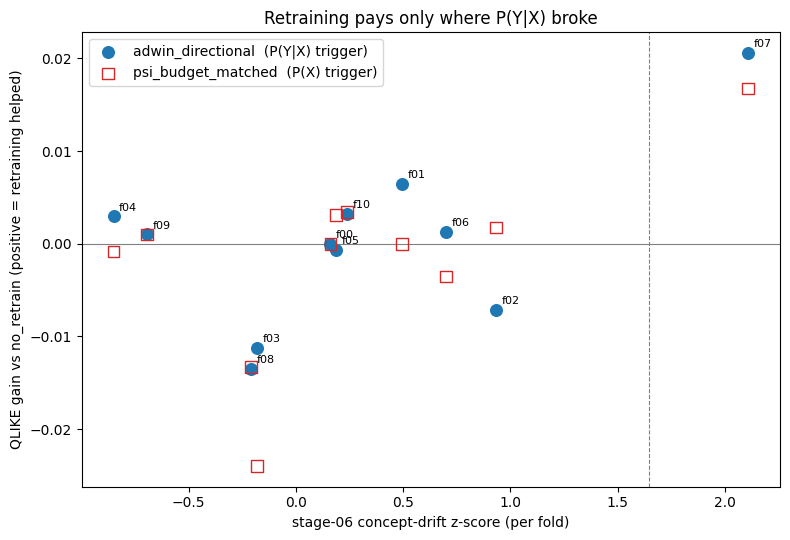

saved: drift_vs_gain.png / retrain_policies.csv / retrain_summary.csv
retrain_policies.csv shape: (2823, 40)


In [11]:
# Drift-vs-gain plot: x = stage-06 concept-drift z-score per fold,
# y = QLIKE improvement over no_retrain. If retraining only pays where
# P(Y|X) actually broke, the points should rise with z.
drift06 = pd.read_csv('data/processed/concept_drift.csv')
drift_z = dict(zip(drift06['fold'], drift06['z']))

def per_fold_gain(name):
    lg = results[name]
    pol = lg['loss'].groupby(fold_ids(lg)).mean().drop(index=-1)
    base = results['no_retrain']['loss'].groupby(fold_ids(results['no_retrain'])).mean().drop(index=-1)
    return base - pol            # positive = retraining helped

gain_adwin = per_fold_gain('adwin_directional')
gain_psi = per_fold_gain('psi_budget_matched')
z = pd.Series(drift_z)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(1.645, color='gray', lw=0.8, ls='--')
ax.scatter(z, gain_adwin, s=70, label='adwin_directional  (P(Y|X) trigger)', zorder=3)
ax.scatter(z, gain_psi, s=70, marker='s', facecolors='none',
           edgecolors='tab:red', label='psi_budget_matched  (P(X) trigger)', zorder=3)
for f in range(11):
    ax.annotate(f'f{f:02d}', (z[f], gain_adwin[f]), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('stage-06 concept-drift z-score (per fold)')
ax.set_ylabel('QLIKE gain vs no_retrain (positive = retraining helped)')
ax.set_title('Retraining pays only where P(Y|X) broke')
ax.legend()
fig.tight_layout()
fig.savefig('data/processed/drift_vs_gain.png', dpi=150)
plt.show()

# exports for later stages
daily = pd.concat({n: results[n][['y_pred', 'y_true', 'loss', 'retrain_triggered', 'n_retrains']]
                   for n in POLICIES}, axis=1)
daily.to_csv('data/processed/retrain_policies.csv')
summary.to_csv('data/processed/retrain_summary.csv')
print('saved: drift_vs_gain.png / retrain_policies.csv / retrain_summary.csv')
print('retrain_policies.csv shape:', daily.shape)


In [12]:
# Sensitivity of adwin_directional to its two extra knobs.
rows = []
for gap in (0.1, 0.2, 0.3):
    for n1 in (21, 42):
        det = AdwinStream(delta=0.002, min_n=30, one_sided=True, gap_min=gap, n1_min=n1)
        trigger, diag = make_adwin_trigger(det)
        lg = simulate_retrain(df, trigger, train_window=1008, start=1008)
        dd = pd.DataFrame(diag)
        f07_fires = dd[(dd['i'] - 1008) // 252 == 7] if len(dd) else dd
        f08_fires = dd[(dd['i'] - 1008) // 252 == 8] if len(dd) else dd
        rows.append({'gap_min': gap, 'n1_min': n1,
                     'n_retrains': int(lg['n_retrains'].iloc[-1]),
                     'mean_QLIKE': round(lg['loss'].mean(), 5),
                     'f07_first': str(f07_fires['date'].iloc[0].date()) if len(f07_fires) else 'NONE',
                     'f08_fires': len(f08_fires)})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))
# reference: no_retrain 0.07495 | adwin_directional(0.2, 21) 0.07448 | oracle 0.07391


 gap_min  n1_min  n_retrains  mean_QLIKE  f07_first  f08_fires
     0.1      21          12     0.07448 2022-04-04          0
     0.1      42           9     0.07526 2022-04-01          0
     0.2      21          12     0.07448 2022-04-04          0
     0.2      42           9     0.07526 2022-04-01          0
     0.3      21          12     0.07448 2022-04-04          0
     0.3      42           9     0.07526 2022-04-01          0
